In [45]:
# Углублённая аналитика: Воронки, Когорты и Сегментация

# Проект: Анализ поведения пользователей в e-commerce

# Цель ноутбука
## В этом ноутбуке проводится углублённый анализ бизнес-метрик на основе очищенного датасета.

# Фокус смещён с изучения структуры данных на оценку эффективности воронки продаж, удержания пользователей и их ценности.

# Основные задачи:
## - построить и проанализировать воронку продаж (view -> cart -> purchase);
## - оценить конверсии в разрезе категорий и брендов для выявления точек роста;
## - провести когортный анализ: удержание покупателей и частота повторных покупок;
## - выполнить RFM-сегментацию для выделения ценных групп пользователей;
## - сформулировать точечные бизнес-рекомендации по улучшению ключевых метрик.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import timedelta

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
path_cleaned = 'C:/Users/golde/pet project/data/processed/cleaned_data.parquet'

df = pd.read_parquet(path_cleaned)

print('Размер датасета:', df.shape)

Размер датасета: (2193682, 20)


In [3]:
# Блок 1: Воронка продаж (Funnel Analysis)

In [4]:
# Общая воронка

In [5]:
# Считаем количество событий по типам
funnel = df['event_type'].value_counts().reindex(['view', 'cart', 'purchase'])

# Считаем конверсии
cr_view_cart = funnel['cart'] / funnel['view'] * 100
cr_cart_purchase = funnel['purchase'] / funnel['cart'] * 100
cr_view_purchase = funnel['purchase'] / funnel['view'] * 100

# Вывод
print(f"Воронка продаж:")
print(f"View:     {funnel['view']:>10,} (100%)")
print(f"Cart:     {funnel['cart']:>10,} ({cr_view_cart:.2f}% от view)")
print(f"Purchase: {funnel['purchase']:>10,} ({cr_cart_purchase:.2f}% от cart)")
print(f"\nОбщая конверсия View -> Purchase: {cr_view_purchase:.2f}%")

Воронка продаж:
View:      2,081,608 (100%)
Cart:         78,783 (3.78% от view)
Purchase:     33,291 (42.26% от cart)

Общая конверсия View -> Purchase: 1.60%


In [34]:
# Cart -> Purchase (42.26%) — отличный показатель.
## Те, кто добавил товар в корзину, с высокой вероятностью завершают покупку.

# View -> Cart (3.78%) — узкое место воронки.
## Из 100 просмотров только ~4 приводят к добавлению в корзину.
## Возможные причины: цены, карточки товаров, отсутствие триггеров ("купить в 1 клик", отзывы).

# Нужно найти способы улучшить конверсию на этапе View -> Cart.

In [6]:
# Воронка по категориям (топ-5)

In [7]:
# Фильтруем топ-5 категорий по просмотрам
top_categories = df['category_level_1'].value_counts().head(5).index

# Считаем воронку для каждой категории
funnel_by_cat = (
    df[df['category_level_1'].isin(top_categories)]
    .groupby(['category_level_1', 'event_type'])
    .size()
    .unstack(fill_value=0)
)

# Добавляем конверсии
funnel_by_cat['cr_view_cart'] = funnel_by_cat['cart'] / funnel_by_cat['view'] * 100
funnel_by_cat['cr_view_purchase'] = funnel_by_cat['purchase'] / funnel_by_cat['view'] * 100

# Показываем результат
funnel_by_cat[['view', 'cart', 'purchase', 'cr_view_cart', 'cr_view_purchase']].round(2)

event_type,view,cart,purchase,cr_view_cart,cr_view_purchase
category_level_1,,,,,
apparel,88786,1062,423,1.20,0.48
appliances,255736,8684,3404,3.40,1.33
computers,125533,2878,1277,2.29,1.02
electronics,740202,44005,18367,5.94,2.48
unknown,679349,18676,8283,2.75,1.22


In [36]:
# Electronics — лидер по всем метрикам:
## 5.94% конверсии в корзину (в 5 раз лучше, чем apparel)
## 2.48% итоговая конверсия в покупку
## Это ядро бизнеса: аудитория целенаправленно выбирает данную категорию товара и покупает.

# Apparel — аутсайдер:
## Всего 1.20% добавляют в корзину, 0.48% покупают.
## Гипотезы: слабый ассортимент, нет размерной сетки, высокая конкуренция с другими площадками.
## Рекомендация: аудит карточек товаров, запуск примерок/возвратов, таргет на лояльную аудиторию.

# Unknown — категория с потенциалом:
## 2.75% в корзину, 1.22% в покупку — лучше среднего, но хуже электроники.
## Если здесь скрыты перспективные товары, их разметка может дать быстрый рост метрик.

# Appliances и Computers — стабильный средний сегмент:
## Конверсии 3.40%/1.33% и 2.29%/1.02% соответственно.
## Можно тестировать кросс-сейл с electronics (например, "к ноутбуку — сумка для его переноски со скидкой").

In [8]:
# Визуализация воронки

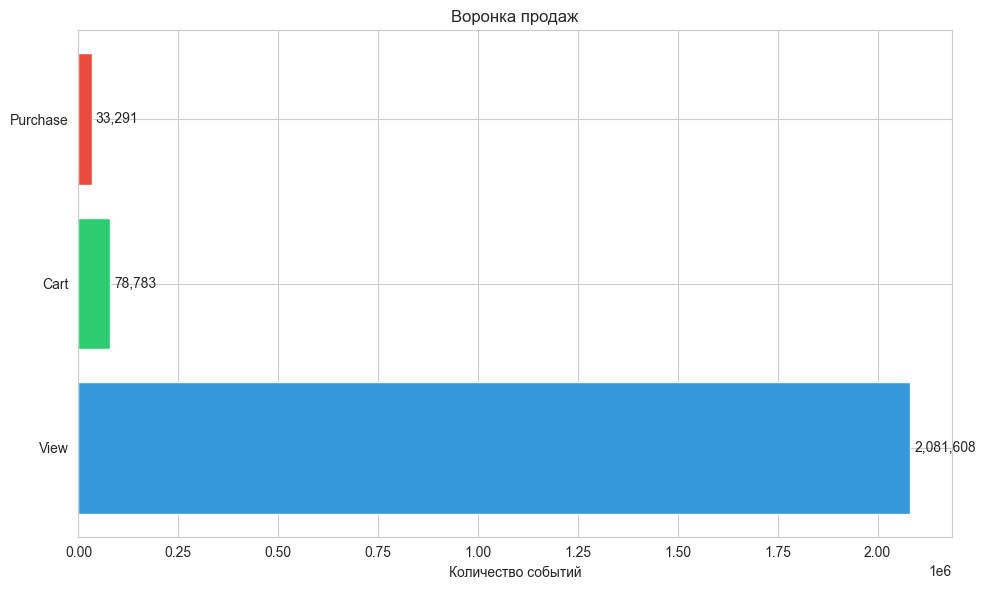

In [9]:
# Простая горизонтальная воронка
labels = ['View', 'Cart', 'Purchase']
values = [funnel['view'], funnel['cart'], funnel['purchase']]

plt.barh(labels, values, color=['#3498db', '#2ecc71', '#e74c3c'])
plt.xlabel('Количество событий')
plt.title('Воронка продаж')
for i, v in enumerate(values):
    plt.text(v + 10000, i, f'{v:,}', va='center')
plt.tight_layout()
plt.show()

In [19]:
# Блок 2: Когортный анализ (Cohort Analysis)

In [11]:
# 1. Находим дату первого события каждого пользователя
user_cohort = df.groupby('user_id')['event_time'].min().reset_index()
user_cohort.columns = ['user_id', 'first_event_date']

# 2. Формируем название когорты в формате 'YYYY-MM' (без Period → без варнингов)
user_cohort['cohort'] = user_cohort['first_event_date'].dt.strftime('%Y-%m')

# 3. Присоединяем когорту к основному датасету
df = df.merge(user_cohort[['user_id', 'cohort']], on='user_id', how='left')

# 4. Считаем номер месяца активности относительно когорты (0, 1, 2...)
df['event_year'] = df['event_time'].dt.year
df['event_month'] = df['event_time'].dt.month
df['cohort_year'] = df['cohort'].str[:4].astype(int)
df['cohort_month_num'] = df['cohort'].str[5:7].astype(int)

df['month_number'] = (df['event_year'] - df['cohort_year']) * 12 + \
                     (df['event_month'] - df['cohort_month_num'])

# 5. Оставляем только пользователей, которые сделали хотя бы одну покупку
purchasers = df[df['event_type'] == 'purchase']['user_id'].unique()
df_purchasers = df[df['user_id'].isin(purchasers)].copy()

print(f"Когорты готовы. Пользователей с покупками: {len(purchasers):,}")
print("Новые столбцы в df:", [c for c in df.columns if 'cohort' in c or 'month_number' in c])

Когорты готовы. Пользователей с покупками: 30,997
Новые столбцы в df: ['cohort', 'cohort_year', 'cohort_month_num', 'month_number']


In [12]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,date,year,month,month_name,day,hour,day_of_week,is_weekend,category_level_1,category_level_2,category_level_3,cohort,event_year,event_month,cohort_year,cohort_month_num,month_number
0,2019-10-01 04:49:23+00:00,view,1004957,2053013555631882655,electronics.smartphone,xiaomi,348.53,518613790,93141b24-e95e-4c4b-8796-33141a727fb5,2019-10-01 00:00:00+00:00,2019,10,October,1,4,Tuesday,False,electronics,smartphone,None,2019-10,2019,10,2019,10,0
1,2019-10-01 03:58:42+00:00,view,26402232,2053013563651392361,unknown,unknown,467.12,555300468,d531c1aa-5461-40eb-b5dd-6507ab023664,2019-10-01 00:00:00+00:00,2019,10,October,1,3,Tuesday,False,unknown,None,None,2019-10,2019,10,2019,10,0
2,2019-10-01 05:28:41+00:00,view,26403381,2053013563651392361,unknown,unknown,95.76,514114758,5dd0b291-09c6-44b2-b8de-002bdf918134,2019-10-01 00:00:00+00:00,2019,10,October,1,5,Tuesday,False,unknown,None,None,2019-10,2019,10,2019,10,0
3,2019-10-01 03:51:05+00:00,view,10201532,2053013553224352013,kids.dolls,llorens,60.46,536806958,1e38622f-52d6-41fd-beac-dac9d242d378,2019-10-01 00:00:00+00:00,2019,10,October,1,3,Tuesday,False,kids,dolls,None,2019-10,2019,10,2019,10,0
4,2019-10-01 03:07:56+00:00,view,17900150,2053013560178508465,construction.tools.generator,senci,1021.33,543027553,a6fba805-3f87-4f1f-8b9a-2e77776a22e5,2019-10-01 00:00:00+00:00,2019,10,October,1,3,Tuesday,False,construction,tools,generator,2019-10,2019,10,2019,10,0


In [13]:
# Матрица удержания (retention)

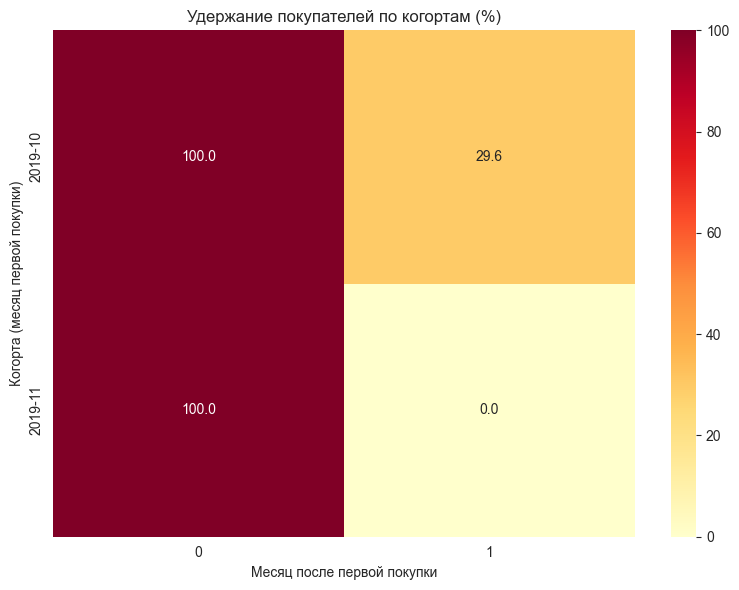

In [38]:
# Считаем удержание: сколько пользователей из каждой когорты вернулись в следующие месяцы
retention = (
    df_purchasers[df_purchasers['event_type'] == 'purchase']
    .groupby(['cohort', 'month_number'])
    .agg({'user_id': 'nunique'})
    .unstack(fill_value=0)
)

# Переименовываем колонки: убираем префикс 'user_id-'
retention.columns = [str(col) for col in retention.columns.get_level_values(1)]

# Нормализуем: делим на размер когорты (месяц 0), чтобы получить проценты
cohort_sizes = retention.iloc[:, 0]  # Количество пользователей в месяце 0
retention_pct = retention.div(cohort_sizes, axis=0) * 100

# Визуализация тепловой карты
plt.figure(figsize=(8, 6))
sns.heatmap(retention_pct.iloc[:10, :3], annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('Удержание покупателей по когортам (%)')
plt.xlabel('Месяц после первой покупки')
plt.ylabel('Когорта (месяц первой покупки)')
plt.tight_layout()
plt.show()

In [39]:
# Матрица показывает % пользователей, совершивших повторную покупку в следующие месяцы.

# Когорта 2019-10 (Октябрь):
## Retention (Month 1) = 29.6%.
## Это хороший показатель: почти каждый 3-й покупатель возвращается за новой покупкой уже в следующем месяце.

# Когорта 2019-11 (Ноябрь):
## Значение 0.0% в колонке "Месяц 1" — это не падение продаж, а артефакт данных.
## Так как датасет заканчивается в ноябре. "Месяц 1" для ноябрьских покупателей — это декабрь, данных по которому у нас физически нет.

# Если 30% людей возвращаются, значит, продукт полезен не разово.

# Можно запускать цепочки реактивации (email/push) через 30 дней после первой покупки именно для тех, кто входит в эти 70% "ушедших".

In [16]:
# Средняя частота покупок по когортам

In [17]:
# Сколько в среднем покупок делает пользователь из каждой когорты
purchase_freq = (
    df_purchasers[df_purchasers['event_type'] == 'purchase']
    .groupby('cohort')
    .agg({
        'user_id': 'nunique',
        'event_type': 'count'  # количество покупок
    })
    .rename(columns={'user_id': 'users', 'event_type': 'purchases'})
)

purchase_freq['avg_purchases_per_user'] = (
    purchase_freq['purchases'] / purchase_freq['users']
).round(2)

purchase_freq

,users,purchases,avg_purchases_per_user
cohort,,,
2019-10,17691,19449,1.10
2019-11,13306,13842,1.04


In [40]:
# Базовый паттерн: ~1 покупка на пользователя
## Обе когорты показывают значения, близкие к 1.0 (1.04–1.10)
## Это значит, что подавляющее большинство покупателей совершают одну покупку за период наблюдения
## Повторные покупки (cross-sell, докупки) происходят редко

# Разница между когортами (1.10 vs 1.04):
## Октябрьская когорта имела +1 месяц времени для повторной покупки → закономерно выше показатель
## Разница в 0.06 покупки — это не поведенческий инсайт, а артефакт разной длины наблюдения

# Низкий repeat purchase rate — зона роста:
## Если 90%+ пользователей покупают только один раз, упускается потенциал LTV
## Возможные причины: нет триггеров на повторную покупку, узкий ассортимент, нет программы лояльности

# Рекомендации:
## Запустить post-purchase коммуникацию, предлагать скидку на следующий заказ.
## Проанализировать, какие товары покупают повторно (расходники, аксессуары), можно сделать на них упор в рекомендациях
## Протестировать программу лояльности: баллы за вторую покупку, реферальная система

In [20]:
# Блок 3: RFM-анализ (сегментация пользователей)

In [21]:
# Расчёт RFM-метрик

In [22]:
# Берём только покупки
purchases_df = df[df['event_type'] == 'purchase'].copy()

# Reference date - последняя дата в датасете
reference_date = purchases_df['event_time'].max() + timedelta(days=1)

# Считаем R, F, M для каждого пользователя
rfm = purchases_df.groupby('user_id').agg({
    'event_time': lambda x: (reference_date - x.max()).days,  # Recency
    'user_session': 'nunique',  # Frequency (количество сессий с покупками)
    'price': 'sum'  # Monetary (общая сумма покупок)
}).rename(columns={
    'event_time': 'recency',
    'user_session': 'frequency',
    'price': 'monetary'
})

print(f"Пользователей с покупками: {len(rfm):,}")
rfm.head()

Пользователей с покупками: 30,997


,recency,frequency,monetary
user_id,,,
395378381,10,1,205.90
396222093,38,1,48.14
433754231,60,1,321.73
440789264,60,1,150.33
443414817,22,1,128.41


In [42]:
# Масштаб базы покупателей:
## 30,997 уникальных пользователей совершили хотя бы одну покупку
## Это ~2.7% от всей аудитории (1.16 млн пользователей) — типичная конверсия для e-commerce

# Паттерн в выборке: все показанные пользователи имеют frequency = 1
## Это подтверждает предыдущий инсайт: большинство покупают один раз
## Разброс по recency (10–60 дней) и monetary (48–322 руб.) показывает неоднородность внутри "одноразовых" покупателей

# Что значат метрики:
## recency: чем меньше, тем "свежее" покупатель (10 дней = недавно покупал, 60 = давно)
## frequency: у всех 1 = нет повторных покупок в периоде наблюдения
## monetary: средний чек варьируется в 6–7 раз — есть и бюджетные, и премиальные покупатели

# Отсутствие "мульти-покупателей" в топе:
## Если даже в первых строках нет пользователей с frequency > 1, значит, лояльная база очень мала
##  Это зона роста: программа удержания может дать быстрый эффект

In [24]:
# Сегментация по квантилям

In [31]:
# Присваиваем баллы 1-4 по каждому измерению (4 = лучший)
rfm['r_score'] = pd.qcut(rfm['recency'], 4, labels=[4, 3, 2, 1], duplicates='drop')
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4], duplicates='drop')
rfm['m_score'] = pd.qcut(rfm['monetary'], 4, labels=[1, 2, 3, 4], duplicates='drop')

# Суммарный скор и сегмент
rfm['total_score'] = rfm['r_score'].astype(int) + rfm['f_score'].astype(int) + rfm['m_score'].astype(int)

def segment_user(row):
    if row['r_score'] == 4 and row['f_score'] >= 3:
        return 'Чемпионы'
    elif row['r_score'] >= 3 and row['f_score'] >= 3:
        return 'Лояльные'
    elif row['r_score'] == 4 and row['f_score'] <= 2:
        return 'Новые'
    elif row['r_score'] <= 2 and row['f_score'] >= 3:
        return 'В зоне риска'
    elif row['r_score'] <= 2 and row['f_score'] <= 2:
        return 'Потерянные'
    else:
        return 'Обычные'

rfm['segment'] = rfm.apply(segment_user, axis=1)

# Показываем распределение
rfm['segment'].value_counts()

segment
Потерянные      8373
В зоне риска    6956
Чемпионы        5426
Новые           4462
Лояльные        3116
Обычные         2664
Name: count, dtype: int64

In [26]:
# Визуализация сегментов

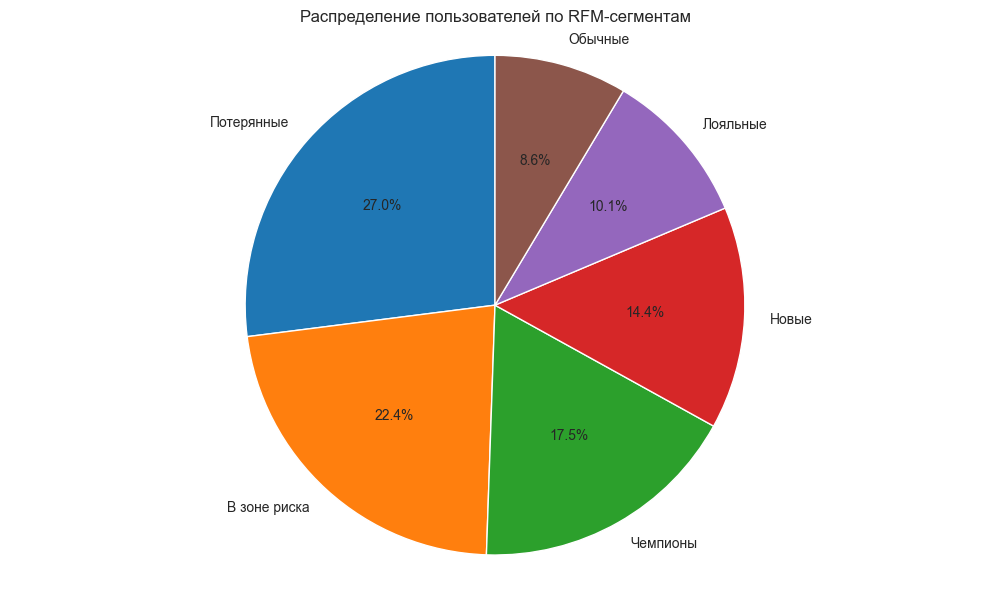

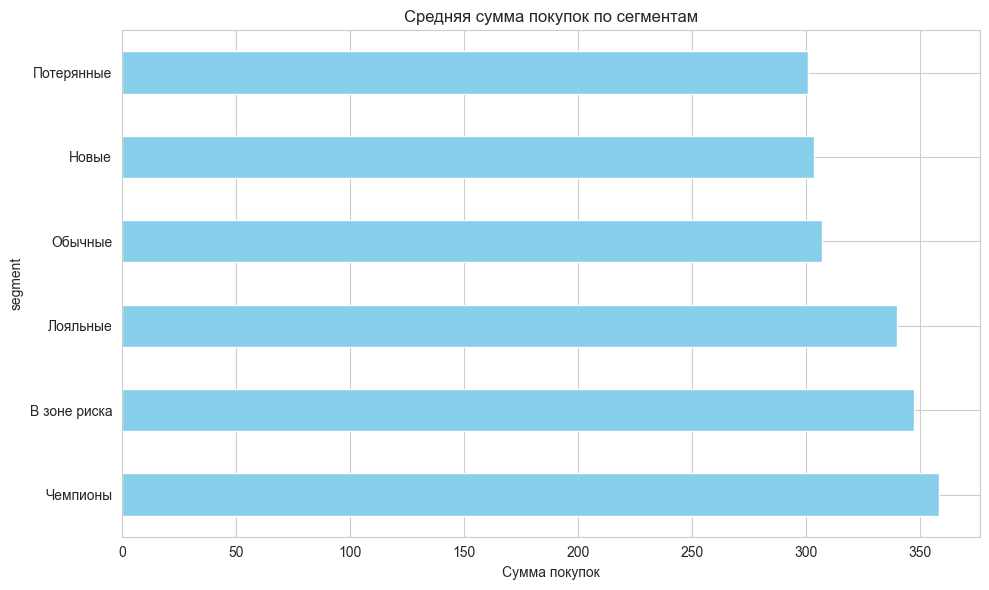

In [32]:
# Доля сегментов
segment_dist = rfm['segment'].value_counts(normalize=True) * 100

plt.pie(segment_dist, labels=segment_dist.index, autopct='%1.1f%%', startangle=90)
plt.title('Распределение пользователей по RFM-сегментам')
plt.axis('equal')
plt.tight_layout()
plt.show()

# Средний чек по сегментам
rfm.groupby('segment')['monetary'].mean().sort_values(ascending=False).plot(
    kind='barh', color='skyblue', title='Средняя сумма покупок по сегментам'
)
plt.xlabel('Сумма покупок')
plt.tight_layout()
plt.show()

In [43]:
# Структура базы: почти половина покупателей "охладела"
## "Потерянные" (27%) + "В зоне риска" (22.4%) = 49.4% аудитории не совершали покупок давно.
## "Обычные" всего 8.6% — база поляризована: пользователи либо активны, либо полностью ушли.
## Типичная ситуация для e-commerce с низким retention: привлечь легко, удержать сложно.

# Ценность сегментов (средняя сумма покупок):
## "Чемпионы" лидируют (~360) — это финансовое ядро бизнеса.
## "В зоне риска" имеют высокую историческую сумму (~345) — это самые дорогие "беглецы". Их возврат даст максимальный ROI.
## "Потерянные" и "Новые" показывают ~300 — базовый уровень чека. У "Новых" есть чёткий потенциал роста до "Лояльных".

# Ключевой бизнес-риск:
## Высокая доля клиентов с большим чеком в сегменте "В зоне риска" означает, что платформа теряет платёжеспособную аудиторию.
## Вероятные причины: отсутствие программы лояльности, рост цен/доставки, ухудшение UX.

# Фокус должен сместиться с acquisition (привлечения) на retention (удержание). 
## Реактивация даже 10% сегмента "В зоне риска" + онбординг "Новых" даст прирост выручки выше, чем удвоение рекламного бюджета.

In [28]:
# Блок 4: Итоги и рекомендации

In [33]:
summary = {
    'Метрика': [
        'Общая конверсия View -> Purchase',
        'Конверсия Cart -> Purchase',
        'Доля пользователей с покупками',
        'Среднее число покупок на покупателя',
        'Доля сегмента "Champions"',
        'Удержание в первый месяц после покупки'
    ],
    'Значение': [
        f"{cr_view_purchase:.2f}%",
        f"{cr_cart_purchase:.2f}%",
        f"{len(purchasers)/df['user_id'].nunique()*100:.1f}%",
        f"{purchase_freq['avg_purchases_per_user'].mean():.2f}",
        f"{(rfm['segment']=='Champions').mean()*100:.1f}%",
        f"{retention_pct.iloc[0, 1] if retention_pct.shape[1] > 1 else 'N/A':.1f}%"
    ]
}

pd.DataFrame(summary)

,Метрика,Значение
0,Общая конверсия View -> Purchase,1.60%
1,Конверсия Cart -> Purchase,42.26%
2,Доля пользователей с покупками,2.7%
3,Среднее число покупок на покупателя,1.07
4,"Доля сегмента ""Champions""",0.0%
5,Удержание в первый месяц после покупки,29.6%


In [44]:
# Финальный вывод

# Ключевые метрики:

# Воронка продаж:
## Общая конверсия View→Purchase: 1.60% (типовая для e-commerce)
## Cart -> Purchase: 42.26% — сильная сторона (чекаут работает отлично)
## View -> Cart: 3.78% — главная точка роста (узкое место воронки)

# Категории:
## Electronics — лидер (5.94% в корзину, 2.48% в покупку), ядро бизнеса
## Apparel — аутсайдер (1.20% в корзину).

# Удержание:
## 29.6% покупателей возвращаются в следующем месяце.
## Среднее число покупок: ~1.1 на пользователя (низкий repeat rate)

# RFM-сегментация:
## 49.4% базы — "Потерянные" и "В зоне риска" (критично)
## 17.5% — "Чемпионы" (самые ценные, ~360 руб. средний чек)
## 22.4% "В зоне риска" имеют высокий исторический чек — приоритет для реактивации

# Рекомендации:
## Улучшить View -> Cart: Добавить триггеры на карточках (отзывы, срочность, рассрочка)
## Запустить CRM-воронки:
### Реактивация "В зоне риска" (персональные скидки)
### Onboarding "Новых" (скидка на 2-й заказ)
### Удержание "Чемпионов": Программа лояльности, VIP-доступ, ранние распродажи